In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


In [2]:
class PairedCIFAR10(Dataset):
    def __init__(self, train=True):
        self.dataset = torchvision.datasets.CIFAR10(
            root="./data",
            train=train,
            download=True
        )

        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        img = self.to_tensor(img)  # [0,1]

        # Convert to grayscale
        gray = img.mean(dim=0, keepdim=True)  # (1,H,W)
        gray = gray.repeat(3, 1, 1)           # (3,H,W)

        # Normalize both to [-1, 1]
        img = img * 2 - 1
        gray = gray * 2 - 1

        return img, gray


In [3]:
train_data = PairedCIFAR10(train=True)
test_data = PairedCIFAR10(train=False)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)


100%|██████████| 170M/170M [00:18<00:00, 9.16MB/s]


In [4]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 32 -> 16
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1), # 16 -> 8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1), # 8 -> 4
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 4 -> 8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8 -> 16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # 16 -> 32
            nn.Tanh()  # output in [-1,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EncoderDecoder().to(device)

mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()

optimizer = optim.Adam(model.parameters(), lr=2e-4)


In [6]:
def train_model(epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0

        for inp, target in train_loader:
            inp, target = inp.to(device), target.to(device)

            output = model(inp)

            loss_mse = mse_loss(output, target)
            loss_l1 = l1_loss(output, target)

            loss = loss_mse + loss_l1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")


In [10]:
train_model(epochs=20)


Epoch [1/20] Loss: 0.0425
Epoch [2/20] Loss: 0.0408
Epoch [3/20] Loss: 0.0400
Epoch [4/20] Loss: 0.0386
Epoch [5/20] Loss: 0.0379
Epoch [6/20] Loss: 0.0364
Epoch [7/20] Loss: 0.0358
Epoch [8/20] Loss: 0.0341
Epoch [9/20] Loss: 0.0338
Epoch [10/20] Loss: 0.0331
Epoch [11/20] Loss: 0.0320
Epoch [12/20] Loss: 0.0297
Epoch [13/20] Loss: 0.0282
Epoch [14/20] Loss: 0.0277
Epoch [15/20] Loss: 0.0269
Epoch [16/20] Loss: 0.0267
Epoch [17/20] Loss: 0.0257
Epoch [18/20] Loss: 0.0255
Epoch [19/20] Loss: 0.0248
Epoch [20/20] Loss: 0.0250


In [11]:
def denorm(x):
    return (x + 1) / 2  # [-1,1] -> [0,1]

def show_results():
    model.eval()
    inp, target = next(iter(test_loader))
    inp, target = inp.to(device), target.to(device)

    with torch.no_grad():
        pred = model(inp)

    inp = denorm(inp).cpu()
    target = denorm(target).cpu()
    pred = denorm(pred).cpu()

    fig, axes = plt.subplots(3, 6, figsize=(14, 7))

    for i in range(6):
        axes[0, i].imshow(np.transpose(inp[i], (1,2,0)))
        axes[0, i].set_title("Input")
        axes[0, i].axis("off")

        axes[1, i].imshow(np.transpose(target[i], (1,2,0)))
        axes[1, i].set_title("Target")
        axes[1, i].axis("off")

        axes[2, i].imshow(np.transpose(pred[i], (1,2,0)))
        axes[2, i].set_title("Output")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()


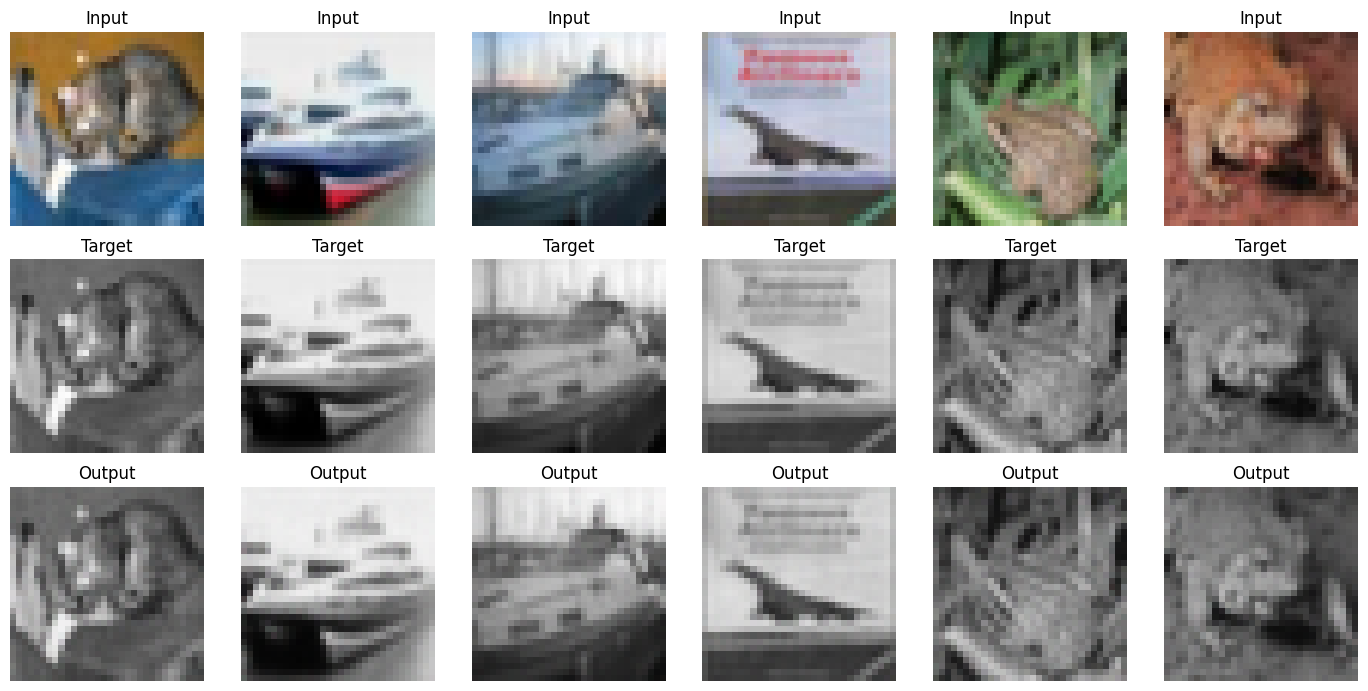

In [12]:
show_results()
